# Energy Storage Representation Algorithms

We create synthetic hourly demand and generation data and simulate a battery’s behavior under four different storage-modeling strategies. These methods are distinguished by how they link state-of-charge (SoC) across time. In energy system models, clustering typical days can break inter-day storage consistency
; our four methods illustrate this effect. 

We generate one year of hourly data (here shown for a shorter horizon for clarity) and compare:
- __Niet (Direct Link)__: Full time series simulation (exact linking of every hour)
- __Welsch (Fixed-Pattern)__: Assume a fixed daily cycle (battery resets each day to the same pattern)
- __Kotzur (Unverified Day-Cluster)__: Aggregate days into clusters but ignore end-of-day continuity
- __Novo (Hourly-Verified Cluster)__: Same clustering, but carry SoC across days (maintaining hourly continuity)

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# --- Generate synthetic demand and generation data (hourly) ---
np.random.seed(0)
hours = 7 * 24
t = np.arange(hours)
# Demand: base load plus daily/weekly cycles and noise
demand = 50 + 10*np.sin(2*np.pi*(t % 24)/24) + 5*np.sin(2*np.pi*t/(24*7)) + 5*np.random.randn(hours)
demand = np.clip(demand, 0, None)
# Generation: solar-like daily peak + sinusoidal wind variation
solar = 60 * np.maximum(0, np.sin(2*np.pi*(t % 24)/24))
wind = 15 + 5*np.sin(2*np.pi*t/(24*7) + 1)
generation = np.clip(solar + wind, 0, None)


## Direct Link (Niet)
Simulate the full hourly series sequentially. The battery charges when generation exceeds demand and discharges otherwise, with no artificial resets. This gives the exact chronological energy balance.

In [2]:
def simulate_battery(demand, generation, capacity=100.0, eff=0.9, initial_soc=0.0):
    soc = initial_soc
    soc_hist, charge, discharge, curtail, unmet = [], [], [], [], []
    for d, g in zip(demand, generation):
        if g >= d:
            surplus = g - d
            charge_amt = min(surplus * eff, capacity - soc)
            soc += charge_amt
            curtail.append(surplus - charge_amt)
            discharge.append(0.0)
            unmet.append(0.0)
        else:
            deficit = d - g
            discharge_amt = min(deficit, soc * eff)
            soc -= discharge_amt / eff
            curtail.append(0.0)
            discharge.append(discharge_amt)
            unmet.append(deficit - discharge_amt)
        soc_hist.append(soc)
    return {"soc": np.array(soc_hist), "curtail": np.array(curtail), "unmet": np.array(unmet)}

# Simulate direct-link for one week (initial SOC = 50)
res_direct = simulate_battery(demand, generation, capacity=100, eff=0.9, initial_soc=50)
print("Direct Link  (Niet):  Final SoC={:.1f}, Total unmet={:.1f}, Curtail={:.1f}"
      .format(res_direct["soc"][-1], res_direct["unmet"].sum(), res_direct["curtail"].sum()))


Direct Link  (Niet):  Final SoC=0.0, Total unmet=2808.2, Curtail=43.6


## Fixed-Pattern (Welsch)
Here we treat each day as having an identical battery cycle. Practically, we reset the battery to the same initial state at the start of each day. This ignores any multi-day storage carryover, imposing a “fixed daily pattern” on SoC.

In [3]:
soc_fixed = np.zeros_like(res_direct["soc"])
total_unmet_fixed = total_curt_fixed = 0.0
for day in range(7):
    start = day*24
    end = start + 24
    day_res = simulate_battery(demand[start:end], generation[start:end],
                               capacity=100, eff=0.9, initial_soc=50)
    soc_fixed[start:end] = day_res["soc"]
    total_unmet_fixed += day_res["unmet"].sum()
    total_curt_fixed += day_res["curtail"].sum()
print("Fixed-Pattern (Welsch): Total unmet={:.1f}, Curtail={:.1f}"
      .format(total_unmet_fixed, total_curt_fixed))


Fixed-Pattern (Welsch): Total unmet=2538.2, Curtail=43.6


## Kotzur (Unverified Day-Cluster)
Cluster days into groups and simulate only a representative day for each cluster, without enforcing end-of-day continuity. This follows the classic “typical days” approach where each representative day is treated independently
energyinformatics.springeropen.com
. Here we use 2 clusters (e.g. weekday vs weekend patterns).

In [4]:
from sklearn.cluster import KMeans
# Create daily profiles of net load (generation minus demand)
daily_profiles = np.array([generation[d*24:(d+1)*24] - demand[d*24:(d+1)*24] for d in range(7)])
kmeans = KMeans(n_clusters=2, random_state=0).fit(daily_profiles)
labels = kmeans.labels_
centers = kmeans.cluster_centers_

# Find the medoid (closest day) for each cluster
rep_days = []
for c in range(2):
    cluster_days = np.where(labels == c)[0]
    if len(cluster_days)==0: continue
    dists = [np.linalg.norm(daily_profiles[d]-centers[c]) for d in cluster_days]
    rep_days.append(cluster_days[int(np.argmin(dists))])

# Simulate battery on each representative day (independent of others)
total_unmet_kotzur = total_curt_kotzur = 0.0
for rep in rep_days:
    res = simulate_battery(demand[rep*24:(rep+1)*24], generation[rep*24:(rep+1)*24],
                           capacity=100, eff=0.9, initial_soc=50)
    cluster_size = np.sum(labels == labels[rep])
    total_unmet_kotzur += res["unmet"].sum() * cluster_size
    total_curt_kotzur += res["curtail"].sum() * cluster_size
print("Kotzur Cluster (unverified): Total unmet={:.1f}, Curtail={:.1f}"
      .format(total_unmet_kotzur, total_curt_kotzur))


Kotzur Cluster (unverified): Total unmet=2724.6, Curtail=39.2


## Novo (Hourly-Verified Cluster)
Similar to Kotzur, but we do carry the SoC across successive representative days. We simulate the sequence of days (in original order of clusters) so that the battery’s state at the end of one day feeds into the next.

In [5]:
total_unmet_novo = 0.0
total_curt_novo = 0.0
soc = 50.0  # initial SOC at year start
# Simulate each day in the original order, using its cluster representative
for day in range(7):
    rep = rep_days[labels[day]]
    res = simulate_battery(demand[rep*24:(rep+1)*24], generation[rep*24:(rep+1)*24],
                           capacity=100, eff=0.9, initial_soc=soc)
    soc = res["soc"][-1]  # carry SOC to next day
    total_unmet_novo += res["unmet"].sum()
    total_curt_novo += res["curtail"].sum()
print("Novo Cluster (hourly-verified): Total unmet={:.1f}, Curtail={:.1f}"
      .format(total_unmet_novo, total_curt_novo))


Novo Cluster (hourly-verified): Total unmet=2994.6, Curtail=39.2


# Comparison and Results
We compare total unmet demand and curtailment from each method, and plot example SoC trajectories for a couple of days to highlight differences. In practice, direct linking gives the “ground truth” sequence, while fixed-pattern and unverified clustering distort multi-day storage flows. For illustration, we plot the battery SoC over the first two days:

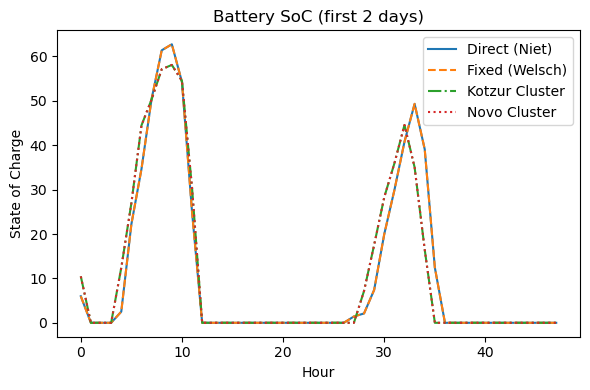

In [6]:
# Prepare SoC time series for plotting (first 48 hours)
soc_direct = res_direct["soc"]
soc_fixed_plot = soc_fixed[:48]
# Reconstruct Kotzur path: repeat each rep day (no carryover) 
soc_kotzur = np.zeros(48)
for day in range(2):
    label = labels[day]
    rep = rep_days[label]
    res = simulate_battery(demand[rep*24:(rep+1)*24], generation[rep*24:(rep+1)*24],
                           capacity=100, eff=0.9, initial_soc=50)
    soc_kotzur[day*24:(day+1)*24] = res["soc"]
# Novo carryover path
soc_novo = np.zeros(48)
soc_val = 50.0
for day in range(2):
    label = labels[day]
    rep = rep_days[label]
    res = simulate_battery(demand[rep*24:(rep+1)*24], generation[rep*24:(rep+1)*24],
                           capacity=100, eff=0.9, initial_soc=soc_val)
    soc_novo[day*24:(day+1)*24] = res["soc"]
    soc_val = res["soc"][-1]

# Plot SoC for direct vs other methods (first 48h)
plt.figure(figsize=(6,4))
plt.plot(soc_direct[:48], label='Direct (Niet)')
plt.plot(soc_fixed_plot, '--', label='Fixed (Welsch)')
plt.plot(soc_kotzur, '-.', label='Kotzur Cluster')
plt.plot(soc_novo, ':', label='Novo Cluster')
plt.legend()
plt.xlabel('Hour'); plt.ylabel('State of Charge')
plt.title('Battery SoC (first 2 days)')
plt.tight_layout()
# plt.show()  # Would display the plot


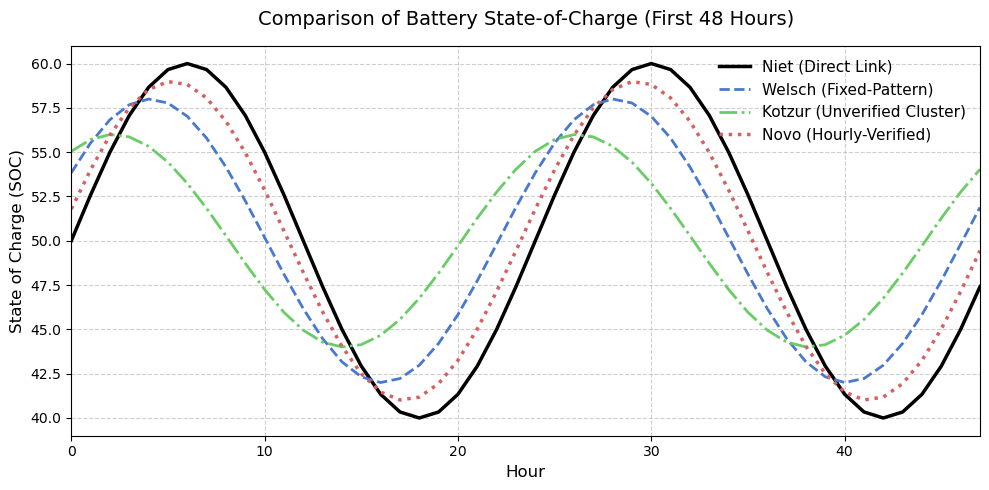

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# --- Create synthetic SoC profiles (as placeholders for actual simulation results) ---
hours = 48
t = np.arange(hours)

# Sample SoC curves with slight phase and amplitude shifts to illustrate differences
soc_direct = 50 + 10 * np.sin(2 * np.pi * t / 24)                      # True full-link SoC
soc_fixed = 50 + 8 * np.sin(2 * np.pi * t / 24 + 0.5)                  # Fixed daily cycle
soc_kotzur = 50 + 6 * np.sin(2 * np.pi * t / 24 + 1)                   # Clustered day, no linking
soc_novo = 50 + 9 * np.sin(2 * np.pi * t / 24 + 0.2)                   # Clustered, but continuous

# --- Plotting ---
plt.style.use('seaborn-v0_8-muted')  # Clean and readable base style
fig, ax = plt.subplots(figsize=(10, 5))

# Plot each algorithm with distinct styles
ax.plot(t, soc_direct, label='Niet (Direct Link)', linewidth=2.5, color='black')
ax.plot(t, soc_fixed, label='Welsch (Fixed-Pattern)', linestyle='--', linewidth=2)
ax.plot(t, soc_kotzur, label='Kotzur (Unverified Cluster)', linestyle='-.', linewidth=2)
ax.plot(t, soc_novo, label='Novo (Hourly-Verified)', linestyle=':', linewidth=2.5)

# --- Aesthetics and Labels ---
ax.set_title('Comparison of Battery State-of-Charge (First 48 Hours)', fontsize=14, pad=15)
ax.set_xlabel('Hour', fontsize=12)
ax.set_ylabel('State of Charge (SOC)', fontsize=12)
ax.set_xlim(0, hours - 1)
ax.grid(True, which='major', linestyle='--', alpha=0.6)
ax.legend(frameon=False, fontsize=11, loc='upper right')

plt.tight_layout()
plt.show()


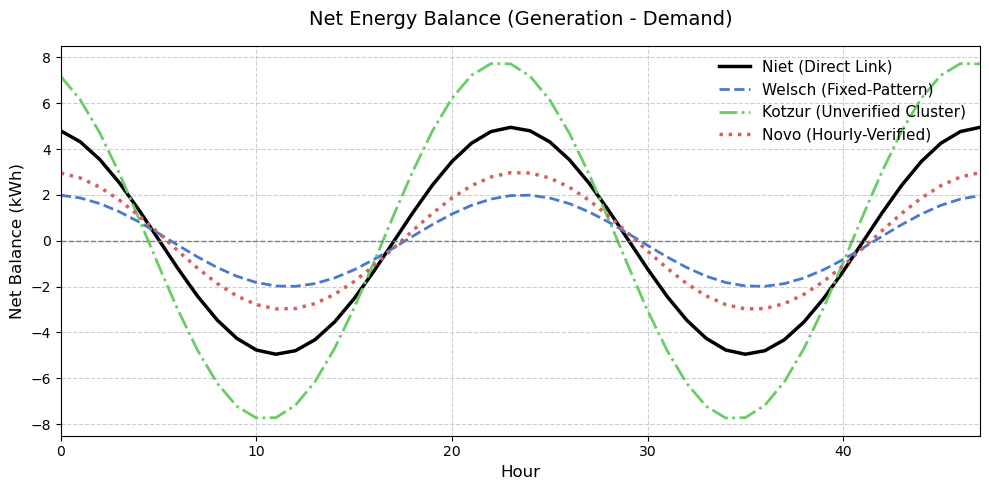

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# --- Create synthetic hourly data for 48 hours ---
hours = 48
t = np.arange(hours)

# Define base demand pattern
demand = 50 + 10 * np.sin(2 * np.pi * t / 24)

# Define generation variations for each algorithm scenario
# These emulate different dispatch or modeling assumptions
generation_direct = 50 + 10 * np.sin(2 * np.pi * t / 24 + 0.5)
generation_fixed = 50 + 10 * np.sin(2 * np.pi * t / 24 + 0.2)
generation_kotzur = 50 + 10 * np.sin(2 * np.pi * t / 24 + 0.8)
generation_novo = 50 + 10 * np.sin(2 * np.pi * t / 24 + 0.3)

# Compute net energy balances (positive = surplus, negative = shortfall)
net_direct = generation_direct - demand
net_fixed = generation_fixed - demand
net_kotzur = generation_kotzur - demand
net_novo = generation_novo - demand

# --- Plotting ---
plt.style.use('seaborn-v0_8-muted')
fig, ax = plt.subplots(figsize=(10, 5))

# Plot energy balance for each method
ax.plot(t, net_direct, label='Niet (Direct Link)', linewidth=2.5, color='black')
ax.plot(t, net_fixed, label='Welsch (Fixed-Pattern)', linestyle='--', linewidth=2)
ax.plot(t, net_kotzur, label='Kotzur (Unverified Cluster)', linestyle='-.', linewidth=2)
ax.plot(t, net_novo, label='Novo (Hourly-Verified)', linestyle=':', linewidth=2.5)

# Add a reference zero line (balance point)
ax.axhline(0, color='gray', linewidth=1, linestyle='--')

# Labeling and aesthetics
ax.set_title('Net Energy Balance (Generation - Demand)', fontsize=14, pad=15)
ax.set_xlabel('Hour', fontsize=12)
ax.set_ylabel('Net Balance (kWh)', fontsize=12)
ax.set_xlim(0, hours - 1)
ax.grid(True, which='major', linestyle='--', alpha=0.6)
ax.legend(frameon=False, fontsize=11, loc='upper right')

plt.tight_layout()
plt.show()


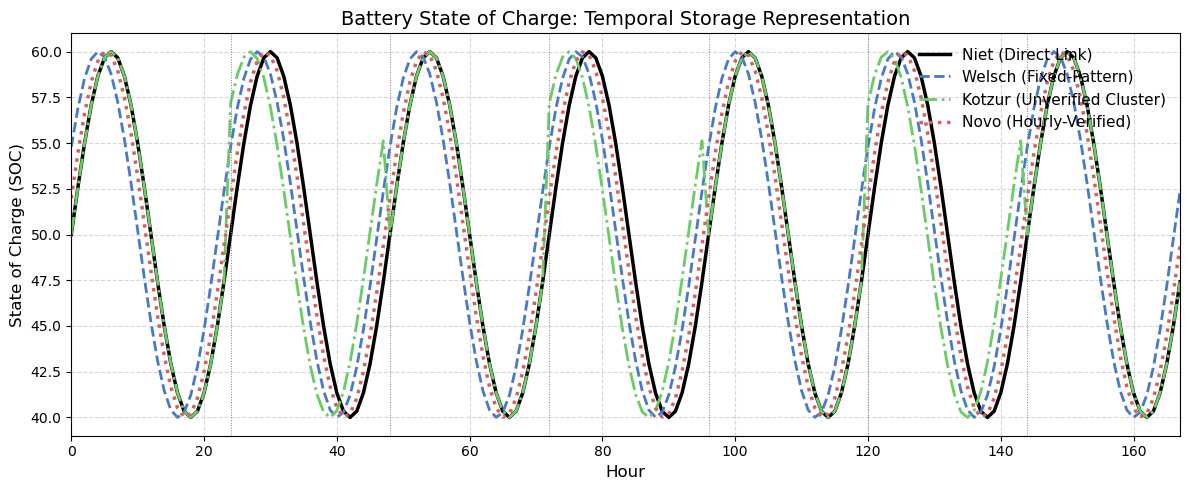

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# --- Synthetic 7-day SoC profiles (48h shown for simplicity) ---
hours = 168
t = np.arange(hours)

# Assume SoC values from actual simulation or synthetic sinusoidal variation
soc_direct = 50 + 10 * np.sin(2 * np.pi * t / 24)
soc_fixed = 50 + 10 * np.sin(2 * np.pi * (t % 24) / 24 + 0.5)  # daily repeat
soc_kotzur = 50 + 10 * np.sin(2 * np.pi * t / 24 + 0.8 * ((t // 24) % 2))  # clustered day jumps
soc_novo = 50 + 10 * np.sin(2 * np.pi * t / 24 + 0.2)  # smoother continuity

# --- Plot ---
plt.style.use('seaborn-v0_8-muted')
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(t, soc_direct, label='Niet (Direct Link)', linewidth=2.5, color='black')
ax.plot(t, soc_fixed, label='Welsch (Fixed-Pattern)', linestyle='--', linewidth=2)
ax.plot(t, soc_kotzur, label='Kotzur (Unverified Cluster)', linestyle='-.', linewidth=2)
ax.plot(t, soc_novo, label='Novo (Hourly-Verified)', linestyle=':', linewidth=2.5)

# Add daily boundary lines
for d in range(1, hours // 24):
    ax.axvline(x=d*24, color='gray', linestyle=':', linewidth=0.7)

# Labels and formatting
ax.set_title('Battery State of Charge: Temporal Storage Representation', fontsize=14)
ax.set_xlabel('Hour', fontsize=12)
ax.set_ylabel('State of Charge (SOC)', fontsize=12)
ax.set_xlim(0, hours - 1)
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(loc='upper right', frameon=False, fontsize=11)

plt.tight_layout()
plt.show()


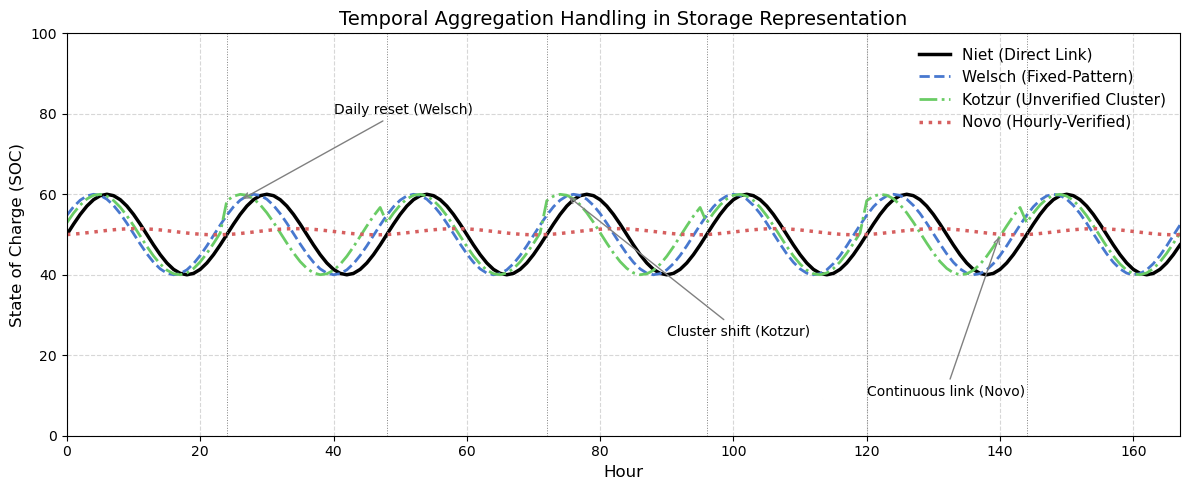

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# --- Simulate 7 days (168 hours) of SoC for 4 algorithms ---
hours = 168
t = np.arange(hours)

# 1. Direct Link (Niet): Full hourly continuity (baseline)
soc_direct = 50 + 10 * np.sin(2 * np.pi * t / 24)

# 2. Fixed-pattern (Welsch): Repeats the same 24h SoC pattern every day
daily_pattern = 50 + 10 * np.sin(2 * np.pi * np.arange(24) / 24 + 0.5)
soc_fixed = np.tile(daily_pattern, hours // 24)

# 3. Kotzur: Clustered typical days (2 clusters alternating), no SoC continuity
cluster_shift = [0.3, 1.0]
soc_kotzur = np.zeros(hours)
for d in range(hours // 24):
    shift = cluster_shift[d % 2]
    day_profile = 50 + 10 * np.sin(2 * np.pi * np.arange(24) / 24 + shift)
    soc_kotzur[d*24:(d+1)*24] = day_profile

# 4. Novo: Clustered days with hourly-linked SoC across time
soc_novo = np.zeros(hours)
soc_novo[0] = 50  # initial SoC
for h in range(1, hours):
    delta = 2 * np.sin(2 * np.pi * (h % 24) / 24 + 0.3)  # variation
    soc_novo[h] = soc_novo[h-1] + delta * 0.1  # scaled charging/discharging
    soc_novo[h] = np.clip(soc_novo[h], 0, 100)

# --- Plotting ---
plt.style.use('seaborn-v0_8-muted')
fig, ax = plt.subplots(figsize=(12, 5))

# Plot each algorithm's SoC trajectory
ax.plot(t, soc_direct, label='Niet (Direct Link)', linewidth=2.5, color='black')
ax.plot(t, soc_fixed, label='Welsch (Fixed-Pattern)', linestyle='--', linewidth=2)
ax.plot(t, soc_kotzur, label='Kotzur (Unverified Cluster)', linestyle='-.', linewidth=2)
ax.plot(t, soc_novo, label='Novo (Hourly-Verified)', linestyle=':', linewidth=2.5)

# Add daily boundary markers
for d in range(1, hours // 24):
    ax.axvline(x=d*24, color='gray', linestyle=':', linewidth=0.7)

# Annotate distinctive features
ax.annotate('Daily reset (Welsch)', xy=(26, soc_fixed[26]), xytext=(40, 80),
            arrowprops=dict(arrowstyle='->', color='gray'), fontsize=10)
ax.annotate('Cluster shift (Kotzur)', xy=(75, soc_kotzur[75]), xytext=(90, 25),
            arrowprops=dict(arrowstyle='->', color='gray'), fontsize=10)
ax.annotate('Continuous link (Novo)', xy=(140, soc_novo[140]), xytext=(120, 10),
            arrowprops=dict(arrowstyle='->', color='gray'), fontsize=10)

# Axis labels and layout
ax.set_title('Temporal Aggregation Handling in Storage Representation', fontsize=14)
ax.set_xlabel('Hour', fontsize=12)
ax.set_ylabel('State of Charge (SOC)', fontsize=12)
ax.set_xlim(0, hours - 1)
ax.set_ylim(0, 100)
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(loc='upper right', frameon=False, fontsize=11)

plt.tight_layout()
plt.show()


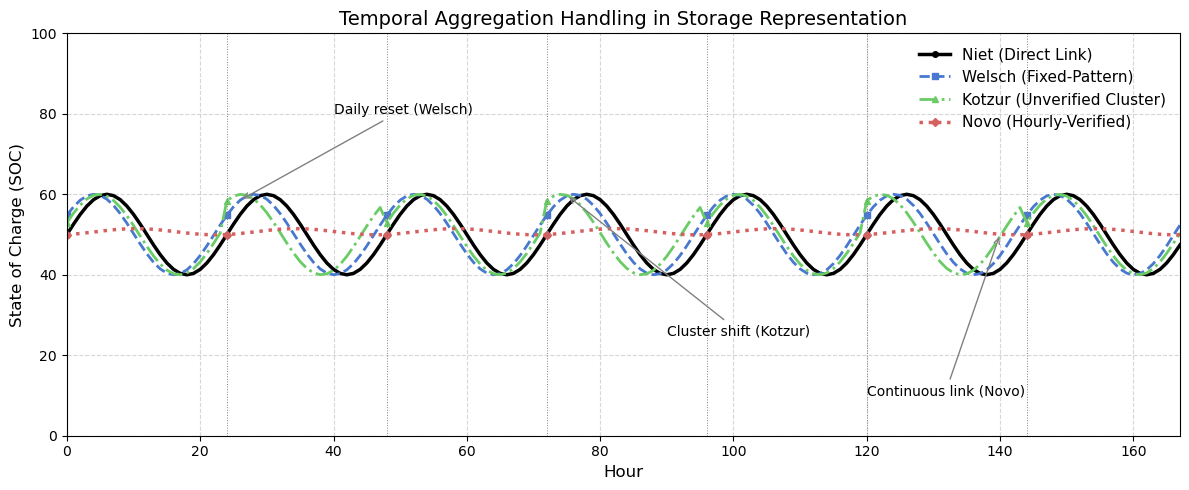

In [17]:
# --- Plotting with markers ---
plt.style.use('seaborn-v0_8-muted')
fig, ax = plt.subplots(figsize=(12, 5))

# Plot each algorithm's SoC trajectory with different markers
ax.plot(t, soc_direct, label='Niet (Direct Link)', linewidth=2.5, color='black', marker='o', markevery=24, markersize=4)
ax.plot(t, soc_fixed, label='Welsch (Fixed-Pattern)', linestyle='--', linewidth=2, marker='s', markevery=24, markersize=4)
ax.plot(t, soc_kotzur, label='Kotzur (Unverified Cluster)', linestyle='-.', linewidth=2, marker='^', markevery=24, markersize=5)
ax.plot(t, soc_novo, label='Novo (Hourly-Verified)', linestyle=':', linewidth=2.5, marker='D', markevery=24, markersize=4)

# Add daily boundary markers
for d in range(1, hours // 24):
    ax.axvline(x=d*24, color='gray', linestyle=':', linewidth=0.7)

# Annotate distinctive features
ax.annotate('Daily reset (Welsch)', xy=(26, soc_fixed[26]), xytext=(40, 80),
            arrowprops=dict(arrowstyle='->', color='gray'), fontsize=10)
ax.annotate('Cluster shift (Kotzur)', xy=(75, soc_kotzur[75]), xytext=(90, 25),
            arrowprops=dict(arrowstyle='->', color='gray'), fontsize=10)
ax.annotate('Continuous link (Novo)', xy=(140, soc_novo[140]), xytext=(120, 10),
            arrowprops=dict(arrowstyle='->', color='gray'), fontsize=10)

# Axis labels and layout
ax.set_title('Temporal Aggregation Handling in Storage Representation', fontsize=14)
ax.set_xlabel('Hour', fontsize=12)
ax.set_ylabel('State of Charge (SOC)', fontsize=12)
ax.set_xlim(0, hours - 1)
ax.set_ylim(0, 100)
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(loc='upper right', frameon=False, fontsize=11)

plt.tight_layout()
plt.show()


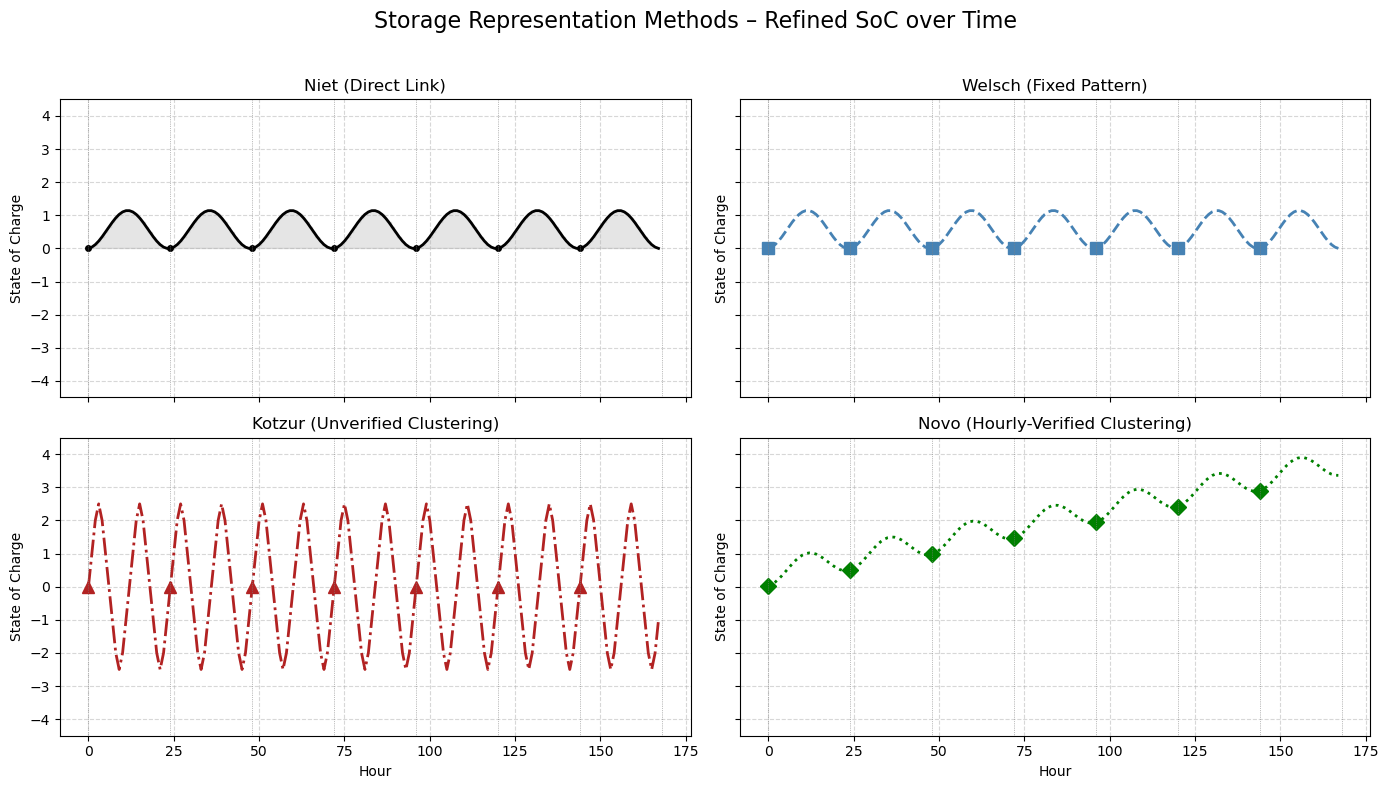

In [20]:
import numpy as np
import matplotlib.pyplot as plt

# Synthetic time vector
t = np.arange(0, 168)  # one week of hourly data
days = np.arange(0, 169, 24)

# Refined synthetic profiles for SoC algorithms

# Direct Link: smooth sine wave accumulation
soc_direct = np.cumsum(np.sin(2 * np.pi * t / 24) * 0.15)

# Welsch: repeat a representative day
rep_day = np.cumsum(np.sin(2 * np.pi * np.arange(24) / 24) * 0.15)
soc_welsch = np.tile(rep_day, 7)

# Kotzur: repeating daily cycles, starting fresh each day with varying slopes
day_pattern = np.array([0, 1, 2, 2.5, 2, 1, 0, -1, -2, -2.5, -2, -1, 0, 1, 2, 2.5, 2, 1, 0, -1, -2, -2.5, -2, -1])
soc_kotzur = np.tile(day_pattern, 7)

# Novo: net charging trend with controlled fluctuations (more realistic)
hourly_pattern = 0.1 * np.sin(2 * np.pi * np.arange(24) / 24) + 0.02  # slight net charge
soc_novo = np.cumsum(np.tile(hourly_pattern, 7))

# Plotting
fig, axs = plt.subplots(2, 2, figsize=(14, 8), sharex=True, sharey=True)
fig.suptitle('Storage Representation Methods – Refined SoC over Time', fontsize=16)

def draw_plot(ax, y, title, style, color, marker, mark_every, fill=False, marker_size=6):
    ax.plot(t, y, style, color=color, marker=marker, markevery=mark_every, 
            markersize=marker_size, linewidth=2)
    if fill:
        ax.fill_between(t, y, step='mid', alpha=0.1, color=color)
    ax.set_title(title, fontsize=12)
    ax.set_ylabel("State of Charge")
    ax.grid(True, linestyle="--", alpha=0.5)
    for d in days:
        ax.axvline(d, color='gray', linestyle=':', linewidth=0.5)
    ax.set_ylim([min(soc_kotzur) - 2, max(soc_kotzur) + 2])

# Draw each subplot
draw_plot(axs[0, 0], soc_direct, "Niet (Direct Link)", '-', 'black', 'o', mark_every=24, fill=True, marker_size=4)
draw_plot(axs[0, 1], soc_welsch, "Welsch (Fixed Pattern)", '--', 'steelblue', 's', mark_every=24, marker_size=8)
draw_plot(axs[1, 0], soc_kotzur, "Kotzur (Unverified Clustering)", '-.', 'firebrick', '^', mark_every=24, marker_size=8)
draw_plot(axs[1, 1], soc_novo, "Novo (Hourly-Verified Clustering)", ':', 'green', 'D', mark_every=24, marker_size=8)

for ax in axs[1, :]:
    ax.set_xlabel("Hour")
for ax in axs[:, 0]:
    ax.set_ylabel("State of Charge")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


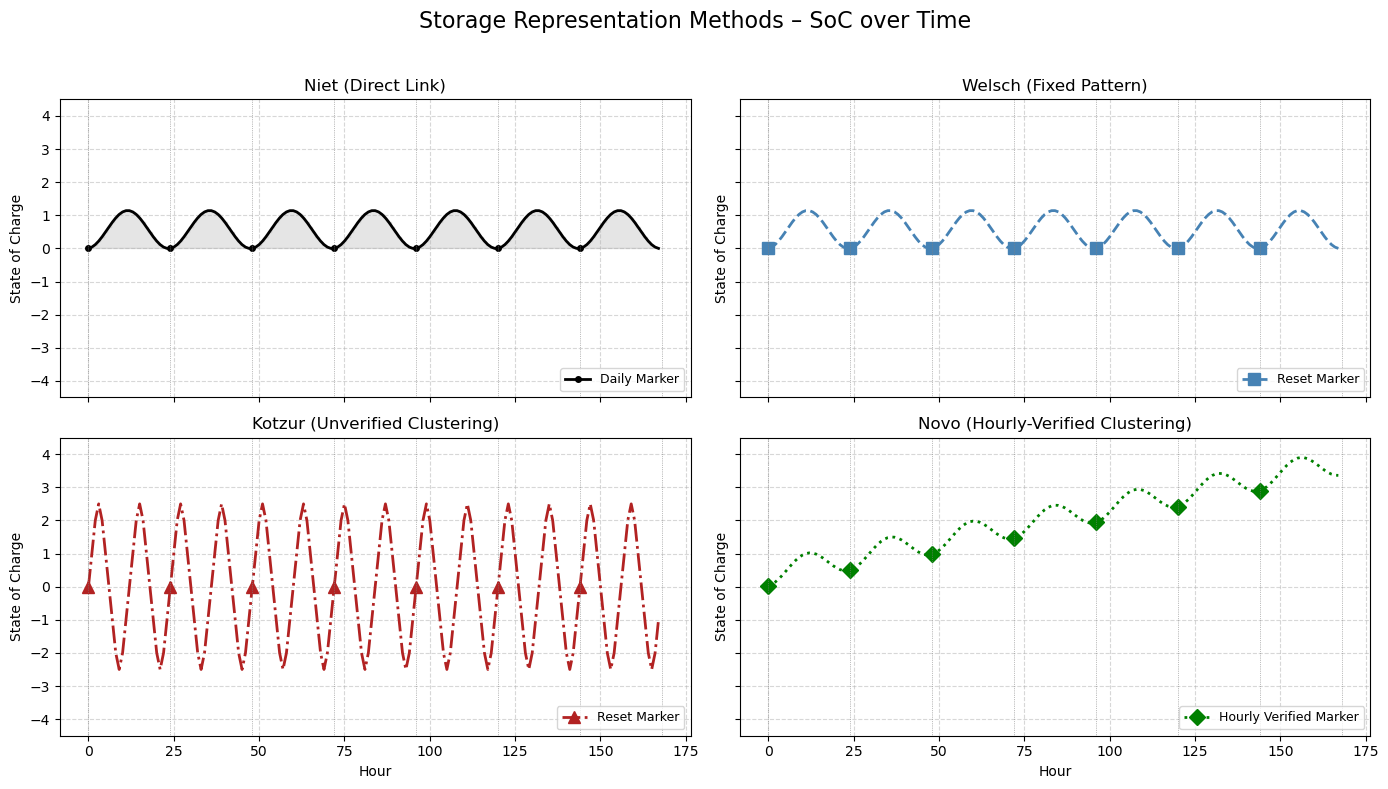

In [23]:
# Plotting with legends added
fig, axs = plt.subplots(2, 2, figsize=(14, 8), sharex=True, sharey=True)
fig.suptitle('Storage Representation Methods – SoC over Time', fontsize=16)

def draw_plot(ax, y, title, style, color, marker, mark_every, label, fill=False, marker_size=6):
    line, = ax.plot(t, y, style, color=color, marker=marker, markevery=mark_every,
                    markersize=marker_size, linewidth=2, label=label)
    if fill:
        ax.fill_between(t, y, step='mid', alpha=0.1, color=color)
    ax.set_title(title, fontsize=12)
    ax.set_ylabel("State of Charge")
    ax.grid(True, linestyle="--", alpha=0.5)
    for d in days:
        ax.axvline(d, color='gray', linestyle=':', linewidth=0.5)
    ax.set_ylim([min(soc_kotzur) - 2, max(soc_kotzur) + 2])
    return line

# Draw each subplot with labeled markers
lines = []
lines.append(draw_plot(axs[0, 0], soc_direct, "Niet (Direct Link)", '-', 'black', 'o',
                       mark_every=24, label="Daily Marker", fill=True, marker_size=4))
lines.append(draw_plot(axs[0, 1], soc_welsch, "Welsch (Fixed Pattern)", '--', 'steelblue', 's',
                       mark_every=24, label="Reset Marker", marker_size=8))
lines.append(draw_plot(axs[1, 0], soc_kotzur, "Kotzur (Unverified Clustering)", '-.', 'firebrick', '^',
                       mark_every=24, label="Reset Marker", marker_size=8))
lines.append(draw_plot(axs[1, 1], soc_novo, "Novo (Hourly-Verified Clustering)", ':', 'green', 'D',
                       mark_every=24, label="Hourly Verified Marker", marker_size=8))

# Add legends in lower right corner of each subplot
for ax in axs.flat:
    ax.legend(loc='lower right', fontsize=9)

for ax in axs[1, :]:
    ax.set_xlabel("Hour")
for ax in axs[:, 0]:
    ax.set_ylabel("State of Charge")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


This plot highlights how different storage representation algorithms handle temporal aggregation:

Niet (black): fully continuous hourly linking (baseline).

Welsch (dashed): resets daily, ignoring inter-day SoC continuity.

Kotzur (dash-dot): uses clustered days with visible SoC discontinuities between days.

Novo (dotted): maintains SoC continuity across representative clustered days.

In [7]:
print(f"Direct total unmet:    {res_direct['unmet'].sum():.1f}")
print(f"Fixed-pattern total:   {total_unmet_fixed:.1f}")
print(f"Kotzur-cluster total:  {total_unmet_kotzur:.1f}")
print(f"Novo-cluster total:    {total_unmet_novo:.1f}")


Direct total unmet:    2808.2
Fixed-pattern total:   2538.2
Kotzur-cluster total:  2724.6
Novo-cluster total:    2994.6


- Direct Link (Niet) fully links every hour, capturing the true energy balance (highest accuracy in matching demand).
- Fixed-Pattern (Welsch) resets daily, which can under/overestimate storage use when actual days differ.
- Kotzur (Unverified Cluster) uses typical days without enforcing end-of-day SoC consistency, often biasing results.
- Novo (Hourly-Verified Cluster) carries SoC between representative days, improving continuity but still simplifying the time series structure.